In [0]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

 ## 2. Extend model;

### 2.1 Add a fourth category of the population for exposed (but not yet infectious) people. 

Thus people become susceptible, exposed, infected, and finally recovered.

**S → E → I → R**

In [0]:
def deriv(y, t, N, beta, gamma, delta):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E  # <-- add this line
    dIdt = delta * E - gamma * I 
    dRdt = gamma * I 
    return dSdt, dEdt, dIdt, dRdt

def plotseird(t, S, E, I, R, D=None, L=None, R0=None, Alpha=None, CFR=None):
  f, ax = plt.subplots(1,1,figsize=(10,4))
  ax.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
  ax.plot(t, E, 'y', alpha=0.7, linewidth=2, label='Exposed')
  ax.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected')
  ax.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered')
  if D is not None:
    ax.plot(t, D, 'k', alpha=0.7, linewidth=2, label='Dead')
    ax.plot(t, S+E+I+R+D, 'c--', alpha=0.7, linewidth=2, label='Total')
  else:
    ax.plot(t, S+E+I+R, 'c--', alpha=0.7, linewidth=2, label='Total')

  ax.set_xlabel('Time (days)')

  ax.yaxis.set_tick_params(length=0)
  ax.xaxis.set_tick_params(length=0)
  ax.grid(b=True, which='major', c='w', lw=2, ls='-')
  legend = ax.legend(borderpad=2.0)
  legend.get_frame().set_alpha(0.5)
  for spine in ('top', 'right', 'bottom', 'left'):
      ax.spines[spine].set_visible(False)
  if L is not None:
      plt.title("Lockdown after {} days".format(L))
  plt.show();

  if R0 is not None or CFR is not None:
    f = plt.figure(figsize=(12,4))
  
  if R0 is not None:
    # sp1
    ax1 = f.add_subplot(121)
    ax1.plot(t, R0, 'b--', alpha=0.7, linewidth=2, label='R_0')

    ax1.set_xlabel('Time (days)')
    ax1.title.set_text('R_0 over time')
    # ax.set_ylabel('Number (1000s)')
    # ax.set_ylim(0,1.2)
    ax1.yaxis.set_tick_params(length=0)
    ax1.xaxis.set_tick_params(length=0)
    ax1.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax1.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
      ax.spines[spine].set_visible(False)

  if Alpha is not None:
    # sp2
    ax2 = f.add_subplot(122)
    ax2.plot(t, Alpha, 'r--', alpha=0.7, linewidth=2, label='alpha')

    ax2.set_xlabel('Time (days)')
    ax2.title.set_text('fatality rate over time')
    # ax.set_ylabel('Number (1000s)')
    # ax.set_ylim(0,1.2)
    ax2.yaxis.set_tick_params(length=0)
    ax2.xaxis.set_tick_params(length=0)
    ax2.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax2.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
      ax.spines[spine].set_visible(False)

    plt.show();   

### 2.2 Add a new parameter for the incubation period.

We add "delta" (incubation) and initiate "E0" variable

In [0]:

delta = 1.0 / 3.0  # incubation period of three days

S0, E0, I0, R0 = 999, 1, 0, 0  # initial conditions: one exposed, rest susceptible

We calculate S, E, I, and R over time:

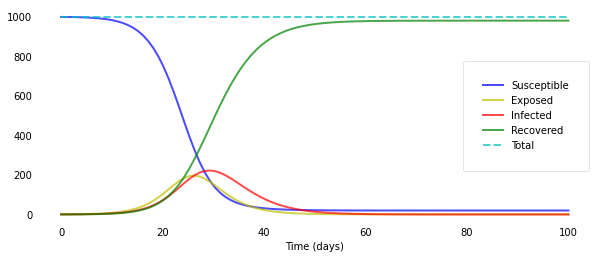

In [0]:
t = np.linspace(0, 100, 100) # Grid of time points (in days)
y0 = S0, E0, I0, R0 # Initial conditions vector

# Integrate the SEIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma, delta))
S, E, I, R = ret.T
plotseird(t, S, E, I, R)

### 2.3 Add a category for those who die, rather than recover, from COVID-19.

And again, a new parameter for the likelihood of death or recovery. This would not be constant (but changes
over time). y-gamma rate 𝛾(𝑡) or p-rho rate rho(t)

In [0]:
# Customized likelihood of Recovery  Delay Differential Equation??
def deriv(y, t, N, beta, gamma, delta, alpha, rho):
    S, E, I, R, D = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma(t) * I - alpha * rho * I # <-- modify this line
    dRdt = (1 - alpha) * gamma(t) * I # <-- modify this line
    dDdt = alpha * rho * I  # <-- add this line
    return dSdt, dEdt, dIdt, dRdt, dDdt

def logistic_R_0(t):
    return (R_0_start-R_0_end) / (1 + np.exp(-k*(-t+x0))) + R_0_end

def gamma(t):
    return logistic_R_0(t) * gamma   

In [0]:
# original 
def deriv(y, t, N, beta, gamma, delta, alpha, rho):
    S, E, I, R, D = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I # <-- modify this line
    dDdt = alpha * rho * I  # <-- add this line
    return dSdt, dEdt, dIdt, dRdt, dDdt

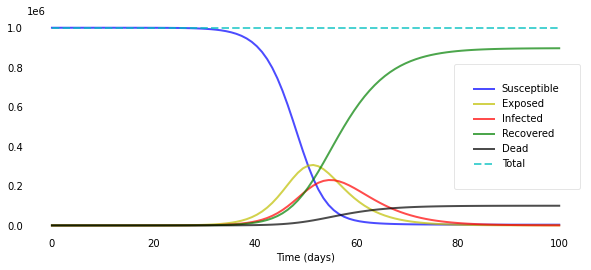

In [0]:

N = 1_000_000
D = 4.0 # infections lasts four days
gamma = 1.0 / D
delta = 1.0 / 5.0  # incubation period of five days
R_0 = 5.0
beta = R_0 * gamma  # R_0 = beta / gamma, so beta = R_0 * gamma
alpha = 0.2  # 10% death rate  <-- add this line
rho = 1/9  # 9 days from infection until death  <-- add this line
S0, E0, I0, R0, D0 = N-1, 1, 0, 0, 0  # initial conditions: one exposed

t = np.linspace(0, 100, 100) # Grid of time points (in days)
y0 = S0, E0, I0, R0, D0 # Initial conditions vector

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma, delta, alpha, rho))
S, E, I, R, D = ret.T

plotseird(t, S, E, I, R, D)

### 2.4Take more factors into account: 

at least population age proportions and two more 
	(e.g. preexisting medical conditions).( parameter )

In [0]:
# same from previous
def deriv(y, t, N, beta, gamma, delta, alpha, rho):
    S, E, I, R, D = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I 
    dDdt = alpha * rho * I  
    return dSdt, dEdt, dIdt, dRdt, dDdt

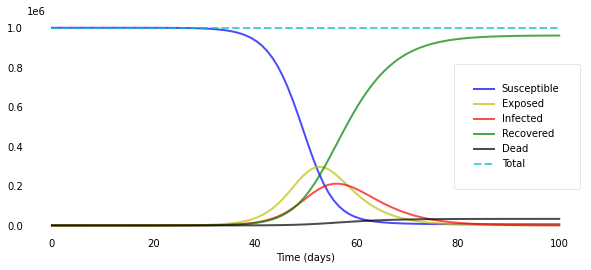

In [0]:

########### Add this #############
# We need 2 things for the simpler approach: Fatality rates by age group and proportion of the total population that is in that age group. 
alpha_by_agegroup = {"0-29": 0.01, "30-59": 0.05, "60-89": 0.2, "89+": 0.3}
proportion_of_agegroup = {"0-29": 0.2, "30-59": 0.4, "60-89": 0.1, "89+": 0.1}
# calculate the overall average fatality rate by adding up the age group fatality rate multiplied with the proportion of the population in that age group:
alpha  = sum(alpha_by_agegroup[i] * proportion_of_agegroup[i] for i in list(alpha_by_agegroup.keys()))
##################

##################### will be used to the next task #################
N = 1_000_000
D = 4.0 # infections lasts four days
gamma = 1.0 / D
delta = 1.0 / 5.0  # incubation period of five days
R_0 = 5.0
beta = R_0 * gamma  # R_0 = beta / gamma, so beta = R_0 * gamma

rho = 1/9  # 9 days from infection until death  <-- add this line
S0, E0, I0, R0, D0 = N-1, 1, 0, 0, 0  # initial conditions: one exposed

t = np.linspace(0, 100, 100) # Grid of time points (in days)
y0 = S0, E0, I0, R0, D0 # Initial conditions vector
###################

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma, delta, alpha, rho))
S, E, I, R, D = ret.T

plotseird(t, S, E, I, R, D)

The number of adult is more than old people , so number of dead is low and  number of recovered is high 

### 2.5 Make as many parameters time-dependent as possible,

 since it’s likely that parameters such as infection rates would fluctuate.

1. R0

In [0]:
R_0_start, k, x0, R_0_end = 5.0, 0.5, 50, 0.5  ## x0 lockdown

In [0]:
def deriv(y, t, N, beta, gamma, delta, alpha, rho):
    S, E, I, R, D = y
    dSdt = -beta(t) * S * I / N
    dEdt = beta(t) * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I
    dDdt = alpha * rho * I
    return dSdt, dEdt, dIdt, dRdt, dDdt

def logistic_R_0(t):
    return (R_0_start-R_0_end) / (1 + np.exp(-k*(-t+x0))) + R_0_end

def beta(t):
    return logistic_R_0(t) * gamma   

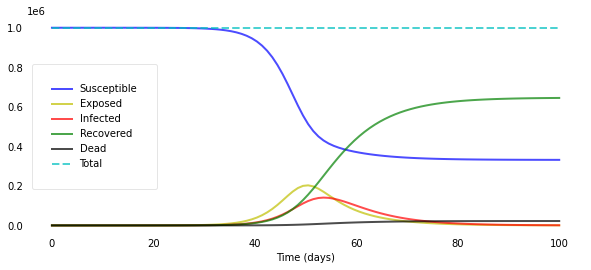

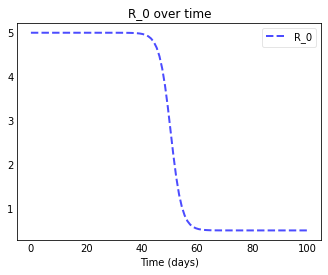

In [0]:


# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma, delta, alpha, rho))
S, E, I, R, D = ret.T
R0_over_time = [logistic_R_0(i) for i in range(len(t))]  # to plot R_0 over time: get function values
plotseird(t, S, E, I, R, D, R0=R0_over_time)

2. Age-Dependent

In [0]:
def deriv(y, t, N, beta, gamma, delta, alpha_opt, rho):
    S, E, I, R, D = y
    def alpha(t):
        return s * I/N + alpha_opt

    dSdt = -beta(t) * S * I / N
    dEdt = beta(t) * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha(t)) * gamma * I - alpha(t) * rho * I
    dRdt = (1 - alpha(t)) * gamma * I
    dDdt = alpha(t) * rho * I
    return dSdt, dEdt, dIdt, dRdt, dDdt


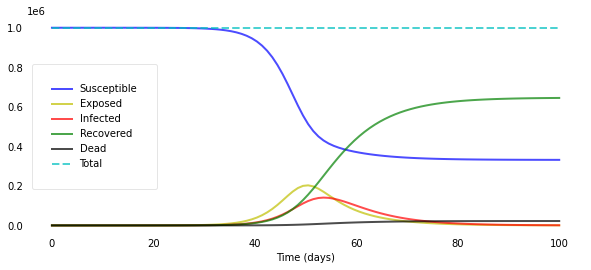

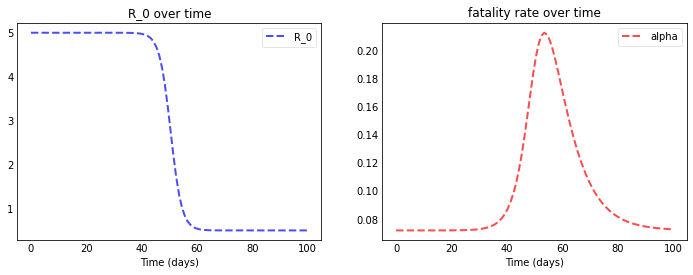

In [0]:
    
s = 1
alpha_opt = sum(alpha_by_agegroup[i] * proportion_of_agegroup[i] for i in list(alpha_by_agegroup.keys()))
Alpha_over_time = [s * I[i]/N + alpha_opt for i in range(len(t))]  # to plot alpha over ti

plotseird(t, S, E, I, R, D, R0=R0_over_time, Alpha=Alpha_over_time)

#### change population
N = S + E + I + R - D

In [0]:
def deriv(y, t, beta, gamma, delta, alpha, rho):
    N, S, E, I, R, D = y
    dNdt = S + E + I + R - D - N
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I
    dDdt = alpha * rho * I
    return dNdt, dSdt, dEdt, dIdt, dRdt, dDdt

In [0]:
N0 = 1_000_000
D = 4.0 # infections lasts four days
gamma = 1.0 / D
delta = 1.0 / 5.0  # incubation period of five days
R_0 = 5.0
beta = R_0 * gamma  # R_0 = beta / gamma, so beta = R_0 * gamma
alpha = 0.06  # 20% death rate
rho = 1/9  # 9 days from infection until death
S0, E0, I0, R0, D0 = N0-1, 1, 0, 0, 0  # initial conditions: one exposed

In [0]:
t = np.linspace(0, 99, 100) # Grid of time points (in days)
y0 = N0, S0, E0, I0, R0, D0 # Initial conditions vector

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(beta, gamma, delta, alpha, rho))
N, S, E, I, R, D = ret.T

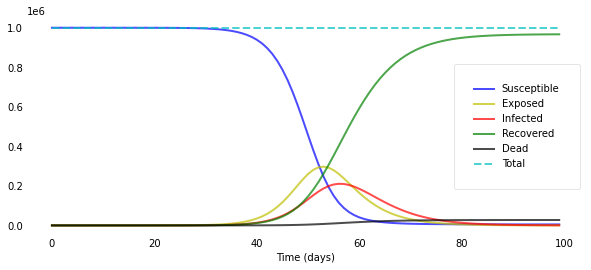

In [0]:
plotseird(t, S, E, I, R, D)

#### change alpha
alpha = total deaths of day t / total cases of day t

In [0]:
def deriv(y, t, N, beta, gamma, delta, rho):
    S, E, I, R, D, alpha, td, tc = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I
    dDdt = alpha * rho * I

    dTDdt = alpha * rho * I
    dTCdt = delta * E

    if t < 30 : dAdt = 0
    else : dAdt = (td/tc) - alpha

    return dSdt, dEdt, dIdt, dRdt, dDdt, dAdt, dTDdt, dTCdt

In [0]:
N = 1_000_000
D = 4.0 # infections lasts four days
gamma = 1.0 / D
delta = 1.0 / 5.0  # incubation period of five days
R_0 = 5.0
beta = R_0 * gamma  # R_0 = beta / gamma, so beta = R_0 * gamma
#alpha = 0.2  # 20% death rate
rho = 1/9  # 9 days from infection until death

S0, E0, I0, R0, D0, alpha0, td0, tc0 = N-1, 1, 0, 0, 0, 0.2, 0.0, 0.0  # initial conditions: one exposed

In [0]:
t = np.linspace(0, 99, 100) # Grid of time points (in days)
y0 = S0, E0, I0, R0, D0, alpha0, td0, tc0 # Initial conditions vector

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma, delta, rho))
S, E, I, R, D, alpha, td, tc = ret.T

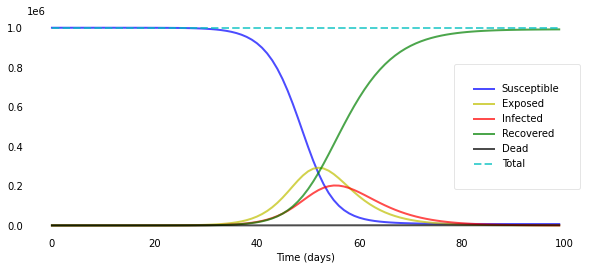

In [0]:
plotseird(t, S, E, I, R, D)

#### change beta
average of beta value \
beta = new cases of day t / infected of day t

In [0]:
def deriv(y, t, N, gamma, delta, alpha, rho):
    S, E, I, R, D, beta, R_0, sb = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I
    dDdt = alpha * rho * I

    # newly infected = delta * E
    if t < 30 : dSBdt = beta
    else : dSBdt = delta * E / I

    dBdt = (sb/(t+1)) - beta

    dR0dt = (sb/(t+1))/gamma - R0

    return dSdt, dEdt, dIdt, dRdt, dDdt, dBdt, dR0dt, dSBdt

In [0]:
N = 1_000_000
D = 4.0 # infections lasts four days
gamma = 1.0 / D
delta = 1.0 / 5.0  # incubation period of five days
#R_0 = 5.0
alpha = 0.06  # 20% death rate
rho = 1/9  # 9 days from infection until death

S0, E0, I0, R0, D0, beta0, R_00, sb0 = N-1, 1, 0, 0, 0, 1.0, 4.0, 1.0  # initial conditions: one exposed

In [0]:
t = np.linspace(0, 99, 100) # Grid of time points (in days)
y0 = S0, E0, I0, R0, D0, beta0, R_00, sb0 # Initial conditions vector

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, gamma, delta, alpha, rho))
S, E, I, R, D, beta, R_0, sb = ret.T

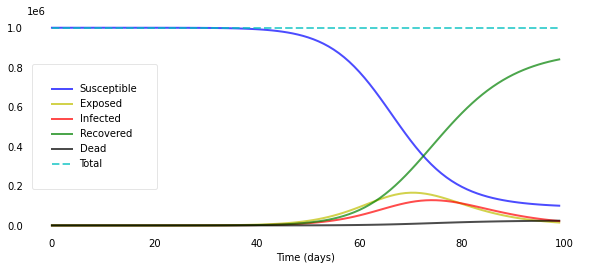

In [0]:
plotseird(t, S, E, I, R, D)

#### change N, alpha, beta

In [0]:
def deriv(y, t, gamma, delta, rho):
    N, S, E, I, R, D, alpha, td, tc, beta, R_0, sb = y
    dNdt = S + E + I + R - D - N
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I
    dDdt = alpha * rho * I

    dTDdt = alpha * rho * I
    dTCdt = delta * E

    if t < 30 : dAdt = 0
    else : dAdt = (td/tc) - alpha

    # newly infected = delta * E
    if t < 30 : dSBdt = beta
    else : dSBdt = delta * E / I

    dBdt = (sb/(t+1)) - beta

    dR0dt = (sb/(t+1))/gamma - R0

    return dNdt, dSdt, dEdt, dIdt, dRdt, dDdt, dAdt, dTDdt, dTCdt, dBdt, dR0dt, dSBdt

In [0]:
N0 = 1_000_000
D = 4.0 # infections lasts four days
gamma = 1.0 / D
delta = 1.0 / 5.0  # incubation period of five days
#R_0 = 5.0
#alpha = 0.2  # 20% death rate
rho = 1/9  # 9 days from infection until death

S0, E0, I0, R0, D0, alpha0, td0, tc0, beta0, R_00, sb0 = N0-1, 1, 0, 0, 0, 0.2, 0, 0, 1.0, 4.0, 1.0  # initial conditions: one exposed

In [0]:
t = np.linspace(0, 99, 100) # Grid of time points (in days)
y0 = N0, S0, E0, I0, R0, D0, alpha0, td0, tc0, beta0, R_00, sb0 # Initial conditions vector

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(gamma, delta, rho))
N, S, E, I, R, D, alpha, td, tc, beta, R_0, sb = ret.T

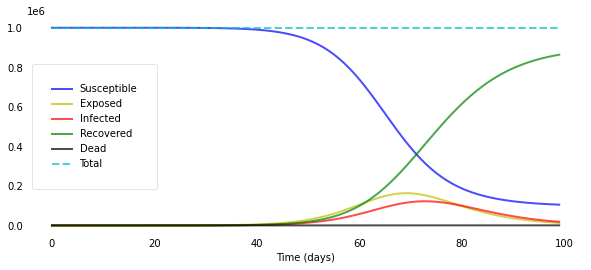

In [0]:
plotseird(t, S, E, I, R, D)

### 2.6 Consider the availability of hospital beds or ventilators which has an impact on the death rate.


Add more time dependent 

3.Beds(t)


In [0]:
# Number of days from infected to critical
i_c_rate = 1/12.0
# Number of days from critical to dead
c_d_rate = 1/7.5
# Number of days from critical to recovered
c_r_rate = 1/6.5

def deriv(y, t, beta, gamma, sigma, N, p_I_to_C, p_C_to_D, Beds):
    S, E, I, C, R, D = y

    dSdt = -beta(t) * I * S / N
    dEdt = beta(t) * I * S / N - sigma * E
    dIdt = sigma * E - i_c_rate * p_I_to_C * I - gamma * (1 - p_I_to_C) * I
    dCdt = i_c_rate * p_I_to_C * I - c_d_rate * p_C_to_D * min(Beds(t), C) - max(0, C-Beds(t)) - (1 - p_C_to_D) * c_r_rate * min(Beds(t), C)
    dRdt = gamma * (1 - p_I_to_C) * I + (1 - p_C_to_D) *c_r_rate * min(Beds(t), C)
    dDdt = c_d_rate * p_C_to_D * min(Beds(t), C) + max(0, C-Beds(t))
    return dSdt, dEdt, dIdt, dCdt, dRdt, dDdt

In [0]:

def Model(days, agegroups, beds_per_100k, R_0_start, k, x0, R_0_end, prob_I_to_C, prob_C_to_D, s):

    def beta(t):
        return logistic_R_0(t) * gamma

    N = sum(agegroups)
    
    def Beds(t):
        beds_0 = beds_per_100k / 100_000 * N
        return beds_0 + s*beds_0*t  # 0.003

    y0 = N-1.0, 1.0, 0.0, 0.0, 0.0, 0.0
    t = np.linspace(0, days-1, days)
    ret = odeint(deriv, y0, t, args=(beta, gamma, sigma, N, prob_I_to_C, prob_C_to_D, Beds))
    S, E, I, C, R, D = ret.T
    R_0_over_time = [beta(i)/gamma for i in range(len(t))]

    return t, S, E, I, C, R, D, R_0_over_time, Beds, prob_I_to_C, prob_C_to_D

percentage going to ICU: 5.0; percentage dying in ICU: 60.0


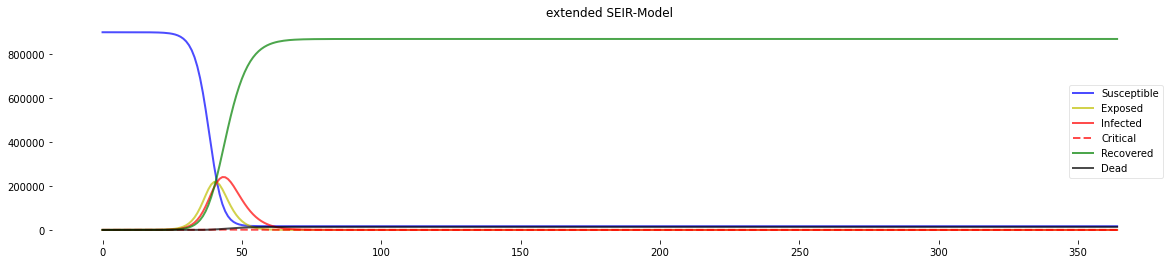

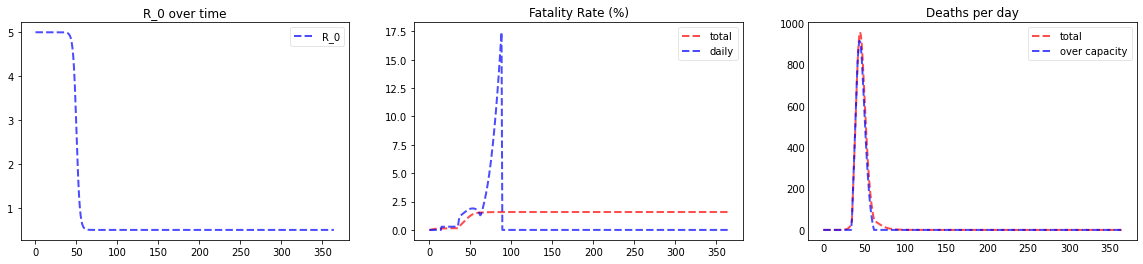

In [0]:

plotter(*Model(days=365, agegroups=[100000, 100000, 100000, 100000, 100000, 100000, 100000, 100000, 100000], 
               beds_per_100k=50, R_0_start=4.0, k=1.0, x0=60, R_0_end=1.0, 
               prob_I_to_C=0.05, prob_C_to_D=0.6, s=0.003))